# ClarityNet: Preliminary Results

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns

/tmp/ipykernel_805742/274779474.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=seen_pesq, ax=axes[0, 0], palette='Blues_d')
/tmp/ipykernel_805742/274779474.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(models, rotation=30, ha='right')
/tmp/ipykernel_805742/274779474.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=seen_stoi, ax=axes[0, 1], palette='Greens_d')
/tmp/ipykernel_805742/274779474.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_

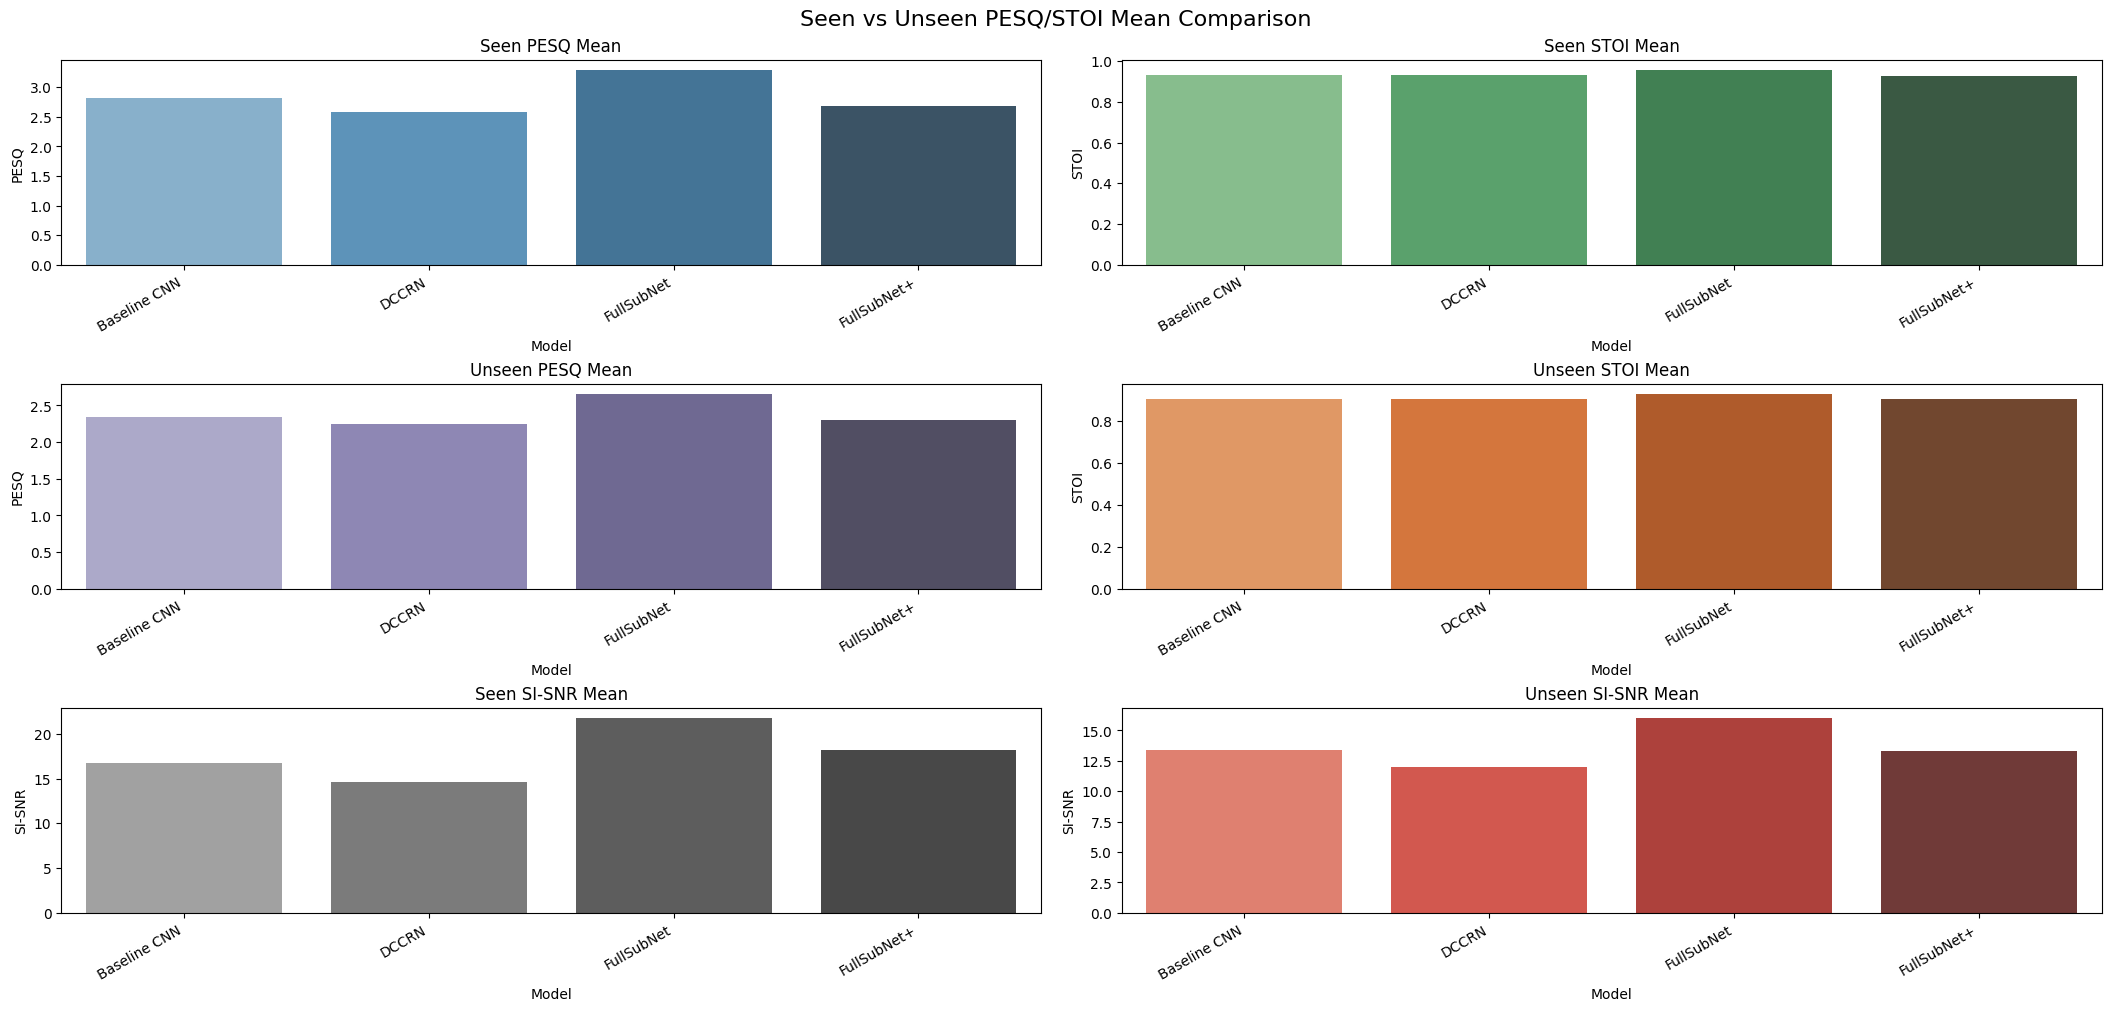

In [8]:
# Load evaluation results and plot seen/unseen PESQ and STOI means across models.
paths = {
    'Baseline CNN': '../results/baseline_cnn_expand_eval/evaluation_results.json',
    'DCCRN': '../results/dccrn_expanded_eval/evaluation_results.json',
    'FullSubNet': '../results/fullsubnet_expand_eval/evaluation_results.json',
    'FullSubNet+': '../results/fullsubnet_plus/evaluation_results.json',
}

results = {}
for model_name, path in paths.items():
    with open(path, 'r') as f:
        data = json.load(f)
    results[model_name] = {
        'seen_pesq_mean': data['seen']['pesq_mean'],
        'seen_stoi_mean': data['seen']['stoi_mean'],
        'unseen_pesq_mean': data['unseen']['pesq_mean'],
        'unseen_stoi_mean': data['unseen']['stoi_mean'],
        'seen_si_snr_mean': data['seen']['si_snr_mean'],
        'unseen_si_snr_mean': data['unseen']['si_snr_mean'],
    }

models = list(results.keys())
seen_pesq = [results[m]['seen_pesq_mean'] for m in models]
seen_stoi = [results[m]['seen_stoi_mean'] for m in models]
unseen_pesq = [results[m]['unseen_pesq_mean'] for m in models]
unseen_stoi = [results[m]['unseen_stoi_mean'] for m in models]
seen_si_snr = [results[m]['seen_si_snr_mean'] for m in models]
unseen_si_snr = [results[m]['unseen_si_snr_mean'] for m in models]

fig, axes = plt.subplots(3, 2, figsize=(21, 10), constrained_layout=True)

sns.barplot(x=models, y=seen_pesq, ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Seen PESQ Mean')
axes[0, 0].set_ylabel('PESQ')
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_xticklabels(models, rotation=30, ha='right')

sns.barplot(x=models, y=seen_stoi, ax=axes[0, 1], palette='Greens_d')
axes[0, 1].set_title('Seen STOI Mean')
axes[0, 1].set_ylabel('STOI')
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_xticklabels(models, rotation=30, ha='right')

sns.barplot(x=models, y=unseen_pesq, ax=axes[1, 0], palette='Purples_d')
axes[1, 0].set_title('Unseen PESQ Mean')
axes[1, 0].set_ylabel('PESQ')
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_xticklabels(models, rotation=30, ha='right')

sns.barplot(x=models, y=unseen_stoi, ax=axes[1, 1], palette='Oranges_d')
axes[1, 1].set_title('Unseen STOI Mean')
axes[1, 1].set_ylabel('STOI')
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_xticklabels(models, rotation=30, ha='right')

sns.barplot(x=models, y=seen_si_snr, ax=axes[2, 0], palette='Greys_d')
axes[2, 0].set_title('Seen SI-SNR Mean')
axes[2, 0].set_ylabel('SI-SNR')
axes[2, 0].set_xlabel('Model')
axes[2, 0].set_xticklabels(models, rotation=30, ha='right')

sns.barplot(x=models, y=unseen_si_snr, ax=axes[2, 1], palette='Reds_d')
axes[2, 1].set_title('Unseen SI-SNR Mean')
axes[2, 1].set_ylabel('SI-SNR')
axes[2, 1].set_xlabel('Model')
axes[2, 1].set_xticklabels(models, rotation=30, ha='right')


fig.suptitle('Seen vs Unseen PESQ/STOI Mean Comparison', fontsize=16)
plt.show()

/tmp/ipykernel_805742/634889762.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=gap_pesq, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_805742/634889762.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(models, rotation=30, ha='right')
/tmp/ipykernel_805742/634889762.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=gap_stoi, ax=axes[1], palette='magma')
/tmp/ipykernel_805742/634889762.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model

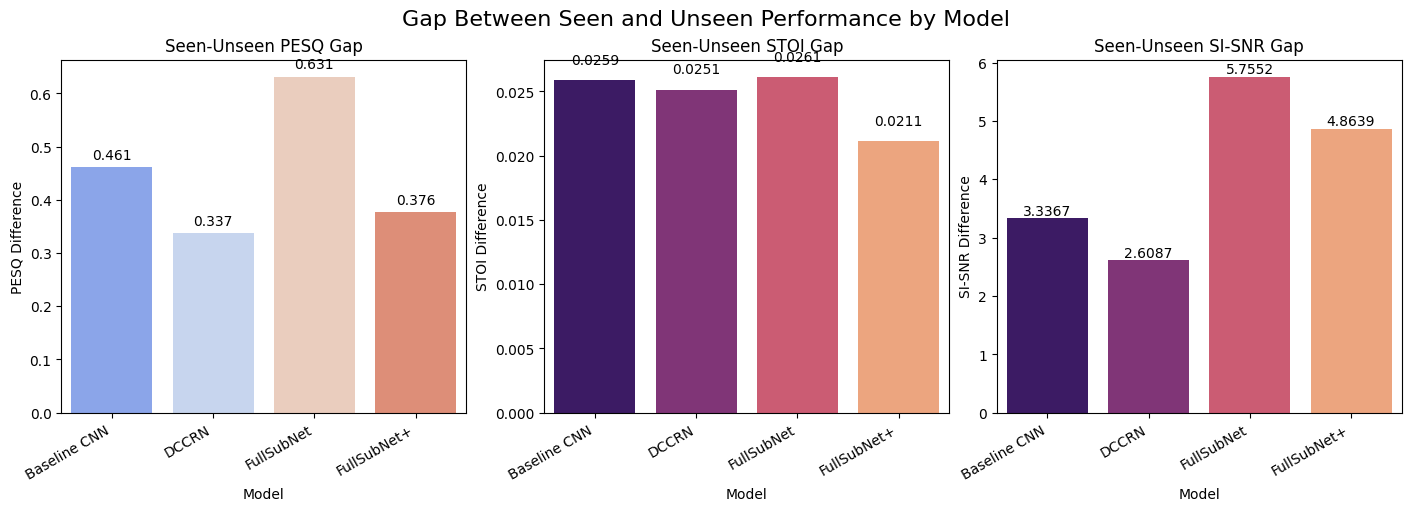

In [11]:
# Plot the seen-unseen gap for PESQ and STOI per model.
gap_pesq = [results[m]['seen_pesq_mean'] - results[m]['unseen_pesq_mean'] for m in models]
gap_stoi = [results[m]['seen_stoi_mean'] - results[m]['unseen_stoi_mean'] for m in models]
gap_si_snr = [results[m]['seen_si_snr_mean'] - results[m]['unseen_si_snr_mean'] for m in models]

fig, axes = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)

sns.barplot(x=models, y=gap_pesq, ax=axes[0], palette='coolwarm')
axes[0].set_title('Seen-Unseen PESQ Gap')
axes[0].set_ylabel('PESQ Difference')
axes[0].set_xlabel('Model')
axes[0].set_xticklabels(models, rotation=30, ha='right')
for i, v in enumerate(gap_pesq):
    axes[0].text(i, v + 0.01 if v >= 0 else v - 0.03, f'{v:.3f}', ha='center', va='bottom' if v >= 0 else 'top')

sns.barplot(x=models, y=gap_stoi, ax=axes[1], palette='magma')
axes[1].set_title('Seen-Unseen STOI Gap')
axes[1].set_ylabel('STOI Difference')
axes[1].set_xlabel('Model')
axes[1].set_xticklabels(models, rotation=30, ha='right')
for i, v in enumerate(gap_stoi):
    axes[1].text(i, v + 0.001 if v >= 0 else v - 0.015, f'{v:.4f}', ha='center', va='bottom' if v >= 0 else 'top')

sns.barplot(x=models, y=gap_si_snr, ax=axes[2], palette='magma')
axes[2].set_title('Seen-Unseen SI-SNR Gap')
axes[2].set_ylabel('SI-SNR Difference')
axes[2].set_xlabel('Model')
axes[2].set_xticklabels(models, rotation=30, ha='right')
for i, v in enumerate(gap_si_snr):
    axes[2].text(i, v + 0.001 if v >= 0 else v - 0.015, f'{v:.4f}', ha='center', va='bottom' if v >= 0 else 'top')

fig.suptitle('Gap Between Seen and Unseen Performance by Model', fontsize=16)
plt.show()

In [ ]:
"""
Plot and compare loss curves across different speech enhancement models.

Usage:
    python plot_model_comparison.py
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Model paths
PATHS = {
    'Baseline CNN': '../results/baseline_cnn_si_snr_eval/training_history.json',
    'DCCRN': '../results/dccrn_si_snr_eval/training_history.json',
    'FullSubNet': '../results/fullsubnet_si_snr_eval/training_history.json',
    'FullSubNet+': '../results/fullsubnet_plus_si_snr_eval/training_history.json',
}

# Color scheme
COLORS = {
    'Baseline CNN': '#1f77b4',  # Blue
    'DCCRN': '#ff7f0e',         # Orange
    'FullSubNet': '#2ca02c',    # Green
    'FullSubNet+': '#d62728',   # Red
}

# Line styles
LINESTYLES = {
    'Baseline CNN': '-',
    'DCCRN': '--',
    'FullSubNet': '-.',
    'FullSubNet+': ':'
}


def load_history(path):
    """Load training history from JSON file."""
    try:
        with open(path, 'r') as f:
            history = json.load(f)
        return history
    except FileNotFoundError:
        print(f"Warning: {path} not found")
        return None
    except json.JSONDecodeError:
        print(f"Warning: {path} is not valid JSON")
        return None


def load_all_histories(paths):
    """Load all training histories."""
    histories = {}
    for model_name, path in paths.items():
        history = load_history(path)
        if history is not None:
            histories[model_name] = history
            print(f"✓ Loaded {model_name}: {len(history.get('train_loss', []))} epochs")
        else:
            print(f"✗ Failed to load {model_name}")
    return histories


def plot_training_loss_comparison(histories, save_path='loss_comparison.png'):
    """Plot training loss curves for all models on same plot."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    
    for model_name, history in histories.items():
        train_loss = history.get('train_loss', [])
        if len(train_loss) == 0:
            continue
        
        epochs = range(1, len(train_loss) + 1)
        ax.plot(
            epochs, train_loss,
            label=model_name,
            color=COLORS.get(model_name, None),
            linestyle=LINESTYLES.get(model_name, '-'),
            linewidth=2.5,
            alpha=0.8
        )
    
    ax.set_xlabel('Epoch', fontsize=13, fontweight='bold')
    ax.set_ylabel('Training Loss', fontsize=13, fontweight='bold')
    ax.set_title('Training Loss Comparison Across Models', fontsize=15, fontweight='bold')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()


def plot_validation_loss_comparison(histories, save_path='val_loss_comparison.png'):
    """Plot validation loss curves (seen and unseen) for all models."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Validation (Seen)
    for model_name, history in histories.items():
        val_seen_loss = history.get('val_seen_loss', [])
        if len(val_seen_loss) == 0:
            continue
        
        epochs = range(1, len(val_seen_loss) + 1)
        axes[0].plot(
            epochs, val_seen_loss,
            label=model_name,
            color=COLORS.get(model_name, None),
            linestyle=LINESTYLES.get(model_name, '-'),
            linewidth=2.5,
            alpha=0.8
        )
    
    axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Validation Loss', fontsize=13, fontweight='bold')
    axes[0].set_title('Validation Loss - Seen Noise', fontsize=14, fontweight='bold')
    axes[0].legend(loc='best', framealpha=0.9)
    axes[0].grid(True, alpha=0.3)
    
    # Validation (Unseen)
    for model_name, history in histories.items():
        val_unseen_loss = history.get('val_unseen_loss', [])
        if len(val_unseen_loss) == 0:
            continue
        
        epochs = range(1, len(val_unseen_loss) + 1)
        axes[1].plot(
            epochs, val_unseen_loss,
            label=model_name,
            color=COLORS.get(model_name, None),
            linestyle=LINESTYLES.get(model_name, '-'),
            linewidth=2.5,
            alpha=0.8
        )
    
    axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Validation Loss', fontsize=13, fontweight='bold')
    axes[1].set_title('Validation Loss - Unseen Noise', fontsize=14, fontweight='bold')
    axes[1].legend(loc='best', framealpha=0.9)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()


def plot_all_losses_grid(histories, save_path='all_losses_grid.png'):
    """Plot train, val (seen), and val (unseen) in a 2x2 grid."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Training Loss
    for model_name, history in histories.items():
        train_loss = history.get('train_loss', [])
        if len(train_loss) == 0:
            continue
        epochs = range(1, len(train_loss) + 1)
        axes[0, 0].plot(epochs, train_loss, label=model_name,
                       color=COLORS.get(model_name), linestyle=LINESTYLES.get(model_name),
                       linewidth=2.5, alpha=0.8)
    
    axes[0, 0].set_xlabel('Epoch', fontweight='bold')
    axes[0, 0].set_ylabel('Loss', fontweight='bold')
    axes[0, 0].set_title('Training Loss', fontsize=13, fontweight='bold')
    axes[0, 0].legend(loc='best')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Validation Loss (Seen)
    for model_name, history in histories.items():
        val_seen_loss = history.get('val_seen_loss', [])
        if len(val_seen_loss) == 0:
            continue
        epochs = range(1, len(val_seen_loss) + 1)
        axes[0, 1].plot(epochs, val_seen_loss, label=model_name,
                       color=COLORS.get(model_name), linestyle=LINESTYLES.get(model_name),
                       linewidth=2.5, alpha=0.8)
    
    axes[0, 1].set_xlabel('Epoch', fontweight='bold')
    axes[0, 1].set_ylabel('Loss', fontweight='bold')
    axes[0, 1].set_title('Validation Loss (Seen Noise)', fontsize=13, fontweight='bold')
    axes[0, 1].legend(loc='best')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Validation Loss (Unseen)
    for model_name, history in histories.items():
        val_unseen_loss = history.get('val_unseen_loss', [])
        if len(val_unseen_loss) == 0:
            continue
        epochs = range(1, len(val_unseen_loss) + 1)
        axes[1, 0].plot(epochs, val_unseen_loss, label=model_name,
                       color=COLORS.get(model_name), linestyle=LINESTYLES.get(model_name),
                       linewidth=2.5, alpha=0.8)
    
    axes[1, 0].set_xlabel('Epoch', fontweight='bold')
    axes[1, 0].set_ylabel('Loss', fontweight='bold')
    axes[1, 0].set_title('Validation Loss (Unseen Noise)', fontsize=13, fontweight='bold')
    axes[1, 0].legend(loc='best')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Generalization Gap (Loss)
    for model_name, history in histories.items():
        val_seen = history.get('val_seen_loss', [])
        val_unseen = history.get('val_unseen_loss', [])
        
        if len(val_seen) == 0 or len(val_unseen) == 0:
            continue
        
        # Compute gap
        min_len = min(len(val_seen), len(val_unseen))
        gap = [val_unseen[i] - val_seen[i] for i in range(min_len)]
        epochs = range(1, min_len + 1)
        
        axes[1, 1].plot(epochs, gap, label=model_name,
                       color=COLORS.get(model_name), linestyle=LINESTYLES.get(model_name),
                       linewidth=2.5, alpha=0.8)
    
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    axes[1, 1].set_xlabel('Epoch', fontweight='bold')
    axes[1, 1].set_ylabel('Gap (Unseen - Seen)', fontweight='bold')
    axes[1, 1].set_title('Generalization Gap (Loss)', fontsize=13, fontweight='bold')
    axes[1, 1].legend(loc='best')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()


def plot_pesq_comparison(histories, save_path='pesq_comparison.png'):
    """Plot PESQ curves for all models."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # PESQ (Seen)
    for model_name, history in histories.items():
        pesq_seen = history.get('val_seen_pesq', [])
        if len(pesq_seen) == 0:
            continue
        epochs = range(1, len(pesq_seen) + 1)
        axes[0].plot(epochs, pesq_seen, label=model_name,
                    color=COLORS.get(model_name), linestyle=LINESTYLES.get(model_name),
                    linewidth=2.5, alpha=0.8)
    
    axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('PESQ Score', fontsize=13, fontweight='bold')
    axes[0].set_title('PESQ - Seen Noise', fontsize=14, fontweight='bold')
    axes[0].set_ylim([0, 4.5])
    axes[0].legend(loc='best', framealpha=0.9)
    axes[0].grid(True, alpha=0.3)
    
    # PESQ (Unseen)
    for model_name, history in histories.items():
        pesq_unseen = history.get('val_unseen_pesq', [])
        if len(pesq_unseen) == 0:
            continue
        epochs = range(1, len(pesq_unseen) + 1)
        axes[1].plot(epochs, pesq_unseen, label=model_name,
                    color=COLORS.get(model_name), linestyle=LINESTYLES.get(model_name),
                    linewidth=2.5, alpha=0.8)
    
    axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('PESQ Score', fontsize=13, fontweight='bold')
    axes[1].set_title('PESQ - Unseen Noise', fontsize=14, fontweight='bold')
    axes[1].set_ylim([0, 4.5])
    axes[1].legend(loc='best', framealpha=0.9)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()


def plot_stoi_comparison(histories, save_path='stoi_comparison.png'):
    """Plot STOI curves for all models."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # STOI (Seen)
    for model_name, history in histories.items():
        stoi_seen = history.get('val_seen_stoi', [])
        if len(stoi_seen) == 0:
            continue
        epochs = range(1, len(stoi_seen) + 1)
        axes[0].plot(epochs, stoi_seen, label=model_name,
                    color=COLORS.get(model_name), linestyle=LINESTYLES.get(model_name),
                    linewidth=2.5, alpha=0.8)
    
    axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('STOI Score', fontsize=13, fontweight='bold')
    axes[0].set_title('STOI - Seen Noise', fontsize=14, fontweight='bold')
    axes[0].set_ylim([0, 1])
    axes[0].legend(loc='best', framealpha=0.9)
    axes[0].grid(True, alpha=0.3)
    
    # STOI (Unseen)
    for model_name, history in histories.items():
        stoi_unseen = history.get('val_unseen_stoi', [])
        if len(stoi_unseen) == 0:
            continue
        epochs = range(1, len(stoi_unseen) + 1)
        axes[1].plot(epochs, stoi_unseen, label=model_name,
                    color=COLORS.get(model_name), linestyle=LINESTYLES.get(model_name),
                    linewidth=2.5, alpha=0.8)
    
    axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('STOI Score', fontsize=13, fontweight='bold')
    axes[1].set_title('STOI - Unseen Noise', fontsize=14, fontweight='bold')
    axes[1].set_ylim([0, 1])
    axes[1].legend(loc='best', framealpha=0.9)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()


def plot_generalization_gaps(histories, save_path='generalization_gaps.png'):
    """Plot generalization gaps (PESQ and STOI) for all models."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # PESQ Gap
    for model_name, history in histories.items():
        gap_pesq = history.get('generalization_gap_pesq', [])
        if len(gap_pesq) == 0:
            # Compute from seen/unseen if gap not available
            pesq_seen = history.get('val_seen_pesq', [])
            pesq_unseen = history.get('val_unseen_pesq', [])
            if len(pesq_seen) > 0 and len(pesq_unseen) > 0:
                min_len = min(len(pesq_seen), len(pesq_unseen))
                gap_pesq = [pesq_seen[i] - pesq_unseen[i] for i in range(min_len)]
            else:
                continue
        
        epochs = range(1, len(gap_pesq) + 1)
        axes[0].plot(epochs, gap_pesq, label=model_name,
                    color=COLORS.get(model_name), linestyle=LINESTYLES.get(model_name),
                    linewidth=2.5, alpha=0.8)
    
    axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Gap (Seen - Unseen)', fontsize=13, fontweight='bold')
    axes[0].set_title('PESQ Generalization Gap', fontsize=14, fontweight='bold')
    axes[0].legend(loc='best', framealpha=0.9)
    axes[0].grid(True, alpha=0.3)
    
    # Add annotation
    axes[0].text(0.02, 0.98, 'Positive = Worse on unseen\nNegative = Better on unseen',
                transform=axes[0].transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # STOI Gap
    for model_name, history in histories.items():
        gap_stoi = history.get('generalization_gap_stoi', [])
        if len(gap_stoi) == 0:
            # Compute from seen/unseen if gap not available
            stoi_seen = history.get('val_seen_stoi', [])
            stoi_unseen = history.get('val_unseen_stoi', [])
            if len(stoi_seen) > 0 and len(stoi_unseen) > 0:
                min_len = min(len(stoi_seen), len(stoi_unseen))
                gap_stoi = [stoi_seen[i] - stoi_unseen[i] for i in range(min_len)]
            else:
                continue
        
        epochs = range(1, len(gap_stoi) + 1)
        axes[1].plot(epochs, gap_stoi, label=model_name,
                    color=COLORS.get(model_name), linestyle=LINESTYLES.get(model_name),
                    linewidth=2.5, alpha=0.8)
    
    axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Gap (Seen - Unseen)', fontsize=13, fontweight='bold')
    axes[1].set_title('STOI Generalization Gap', fontsize=14, fontweight='bold')
    axes[1].legend(loc='best', framealpha=0.9)
    axes[1].grid(True, alpha=0.3)
    
    # Add annotation
    axes[1].text(0.02, 0.98, 'Positive = Worse on unseen\nNegative = Better on unseen',
                transform=axes[1].transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    plt.show()


def print_summary_statistics(histories):
    """Print summary statistics for all models."""
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80)
    
    for model_name, history in histories.items():
        print(f"\n{model_name}:")
        print("-" * 40)
        
        # Training loss
        train_loss = history.get('train_loss', [])
        if len(train_loss) > 0:
            print(f"  Training Loss:")
            print(f"    Initial: {train_loss[0]:.6f}")
            print(f"    Final:   {train_loss[-1]:.6f}")
            print(f"    Min:     {min(train_loss):.6f} (epoch {train_loss.index(min(train_loss))+1})")
        
        # Validation loss (seen)
        val_seen_loss = history.get('val_seen_loss', [])
        if len(val_seen_loss) > 0:
            best_epoch = val_seen_loss.index(min(val_seen_loss)) + 1
            print(f"  Val Loss (Seen):")
            print(f"    Initial: {val_seen_loss[0]:.6f}")
            print(f"    Final:   {val_seen_loss[-1]:.6f}")
            print(f"    Best:    {min(val_seen_loss):.6f} (epoch {best_epoch})")
        
        # Validation loss (unseen)
        val_unseen_loss = history.get('val_unseen_loss', [])
        if len(val_unseen_loss) > 0:
            print(f"  Val Loss (Unseen):")
            print(f"    Initial: {val_unseen_loss[0]:.6f}")
            print(f"    Final:   {val_unseen_loss[-1]:.6f}")
            print(f"    Best:    {min(val_unseen_loss):.6f} (epoch {val_unseen_loss.index(min(val_unseen_loss))+1})")
        
        # PESQ
        pesq_seen = history.get('val_seen_pesq', [])
        pesq_unseen = history.get('val_unseen_pesq', [])
        if len(pesq_seen) > 0 and len(pesq_unseen) > 0:
            print(f"  PESQ:")
            print(f"    Seen (final):   {pesq_seen[-1]:.3f}")
            print(f"    Unseen (final): {pesq_unseen[-1]:.3f}")
            print(f"    Gap:            {pesq_seen[-1] - pesq_unseen[-1]:+.3f}")
        
        # STOI
        stoi_seen = history.get('val_seen_stoi', [])
        stoi_unseen = history.get('val_unseen_stoi', [])
        if len(stoi_seen) > 0 and len(stoi_unseen) > 0:
            print(f"  STOI:")
            print(f"    Seen (final):   {stoi_seen[-1]:.3f}")
            print(f"    Unseen (final): {stoi_unseen[-1]:.3f}")
            print(f"    Gap:            {stoi_seen[-1] - stoi_unseen[-1]:+.3f}")
        
        # Epochs trained
        print(f"  Total epochs: {len(train_loss)}")
    
    print("\n" + "="*80)


def main():
    """Main function to generate all plots."""
    print("="*80)
    print("LOADING TRAINING HISTORIES")
    print("="*80)
    
    # Load all histories
    histories = load_all_histories(PATHS)
    
    if len(histories) == 0:
        print("\n❌ No histories loaded. Check file paths.")
        return
    
    print(f"\n✓ Successfully loaded {len(histories)} model histories\n")
    
    # Create output directory
    output_dir = Path('../plots/model_comparison')
    output_dir.mkdir(parents=True, exist_ok=True)
    
    print("="*80)
    print("GENERATING PLOTS")
    print("="*80)
    print()
    
    # Generate all plots
    plot_training_loss_comparison(histories, output_dir / 'training_loss_comparison.png')
    plot_validation_loss_comparison(histories, output_dir / 'validation_loss_comparison.png')
    plot_all_losses_grid(histories, output_dir / 'all_losses_grid.png')
    
    # Check if PESQ/STOI data available
    has_metrics = any('val_seen_pesq' in h for h in histories.values())
    
    if has_metrics:
        plot_pesq_comparison(histories, output_dir / 'pesq_comparison.png')
        plot_stoi_comparison(histories, output_dir / 'stoi_comparison.png')
        plot_generalization_gaps(histories, output_dir / 'generalization_gaps.png')
    else:
        print("\nℹ️  No PESQ/STOI data found, skipping metric plots")
    
    # Print summary
    print_summary_statistics(histories)
    
    print("\n" + "="*80)
    print(f"✓ ALL PLOTS SAVED TO: {output_dir}")
    print("="*80)


# if __name__ == "__main__":
main()